# Hotel Review Analysis Notebook
This notebook demonstrates how the project:
- Loads data from CSV
- Stores it in a SQL database
- Retrieves and processes the data
- Produces outputs such as word frequencies and visualisations

### Required imports

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent  # go up from /notebooks → project root
sys.path.append(str(BASE_DIR))

print(BASE_DIR)
from src.cleaning import clean_text_column, tokenize_column
from src.analysis import get_top_words
from src.visualisation import generate_wordcloud
from src.output import save_word_frequencies, save_cleaned_data
from src.data_loader import load_sql_data_from_db

C:\Users\alexs\OneDrive\Documents\2-Data-Analysis\Hotel-Review-Analysis
C:\Users\alexs\OneDrive\Documents\2-Data-Analysis\Hotel-Review-Analysis\data\hotel_reviews.db


## Load the dataset

In [2]:
df = load_sql_data_from_db()
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Cleaning
- Creates a new column "clean" from "Review"
- Removes non-alphabetic characters in "clean"
- Transforms all characters to lowercase in "clean".

In [3]:
df = clean_text_column(df, "Review")
df.head()

,Review,Rating,clean
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not experience hotel monaco seattl...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...


## Tokenize
- Creates a new column "tokens" from "clean".
- Splits strings into a list of words.


In [4]:
df = tokenize_column(df, "clean")
df.head()

,Review,Rating,clean,tokens
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,"[nothing, special, charge, diamond, member, hi..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not experience hotel monaco seattl...,"[nice, rooms, experience, hotel, monaco, seatt..."
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game..."


## Analysis
- Finds the top words within the dataframe.

In [5]:
top_words = get_top_words(df["tokens"])
top_words

[('hotel', 48920),
 ('room', 34347),
 ('great', 21097),
 ('good', 16990),
 ('staff', 16216),
 ('stay', 15160),
 ('nice', 12412),
 ('rooms', 12031),
 ('location', 11045),
 ('stayed', 10469),
 ('service', 9980),
 ('time', 9834),
 ('night', 9739),
 ('beach', 9597),
 ('day', 9551),
 ('clean', 9364),
 ('breakfast', 9274),
 ('food', 9010),
 ('like', 8114),
 ('resort', 7936)]

## Visualisation
- Generates a word cloud from the "tokens" column.

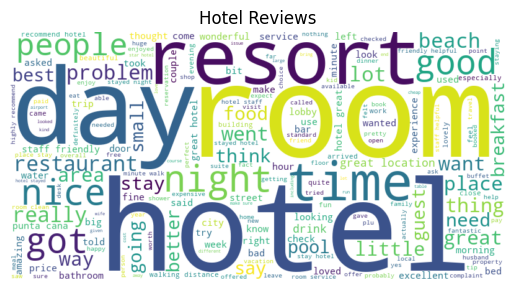

In [6]:
generate_wordcloud(df["tokens"], title="Hotel Reviews")